Shape Function Matrix:
Matrix([[1 - 3*x/L + 2*x**2/L**2, 4*x/L - 4*x**2/L**2, -x/L + 2*x**2/L**2]])
Stiffness Matrix:
⎡ 7⋅A⋅E   -8⋅A⋅E     A⋅E  ⎤
⎢ ─────   ───────    ───  ⎥
⎢  3⋅L      3⋅L      3⋅L  ⎥
⎢                         ⎥
⎢-8⋅A⋅E   16⋅A⋅E   -8⋅A⋅E ⎥
⎢───────  ──────   ───────⎥
⎢  3⋅L     3⋅L       3⋅L  ⎥
⎢                         ⎥
⎢  A⋅E    -8⋅A⋅E    7⋅A⋅E ⎥
⎢  ───    ───────   ───── ⎥
⎣  3⋅L      3⋅L      3⋅L  ⎦


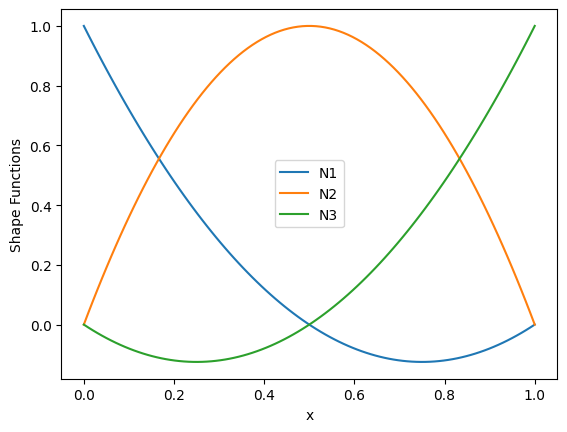

In [ ]:
# STIFFNESS MATRIX AND SHAPE FUNCTION FOR TRUSS ELEMENT

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# Defining symbols
A, E, L, x = sp.symbols('A E L x')

# Input number of nodes
nodes = 3

# Defining Matrices
x_matrix = sp.Matrix([x**i for i in range(nodes)]).reshape(1, nodes)

# Compute x_values
x_values = [i * (L / (nodes - 1)) for i in range(nodes)]

# Construct DA_matrix
DA_matrix = sp.Matrix([x_matrix.subs(x, x_values[i]) for i in range(nodes)])

# Compute the inverse
DA_inv = DA_matrix.inv()

# Print Shape Function Matrix
Shape_function = x_matrix * DA_inv
print("Shape Function Matrix:")
print(Shape_function)

# Generating numeric x values for the plot
x_value_numeric = np.linspace(0, 1, 100)

# Plotting the Shape Functions
for i in range(nodes):
  shape = Shape_function[0, i]
  N = shape.subs(L, 1)
  N_values = [N.subs(x, x_value) for x_value in x_value_numeric]
  plt.plot(x_value_numeric, N_values, label=f'N{i+1}')
  plt.xlabel('x')
  plt.ylabel('Shape Functions')
  plt.legend()

# B and B_Transpose Matrix
B_matrix = sp.diff(Shape_function, x)
B_transpose = B_matrix.T

# Printing Stiffness Matrix
K = A * E * B_transpose * B_matrix
K = sp.integrate(K, (x, 0, L))
print("Stiffness Matrix:")
sp.pprint(K)

# Show the Plot
plt.show()

Shape Function Matrix:
Matrix([[1 - 23*x**2/L**2 + 66*x**3/L**3 - 68*x**4/L**4 + 24*x**5/L**5, x - 6*x**2/L + 13*x**3/L**2 - 12*x**4/L**3 + 4*x**5/L**4, 16*x**2/L**2 - 32*x**3/L**3 + 16*x**4/L**4, -8*x**2/L + 32*x**3/L**2 - 40*x**4/L**3 + 16*x**5/L**4, 7*x**2/L**2 - 34*x**3/L**3 + 52*x**4/L**4 - 24*x**5/L**5, -x**2/L + 5*x**3/L**2 - 8*x**4/L**3 + 4*x**5/L**4]])
Stiffness Matrix:
⎡ 5092⋅E⋅I   1138⋅E⋅I   -512⋅E⋅I    384⋅E⋅I   -1508⋅E⋅I    242⋅E⋅I  ⎤
⎢ ────────   ────────   ─────────   ───────   ──────────   ───────  ⎥
⎢      3          2          3          2           3           2   ⎥
⎢  35⋅L       35⋅L        5⋅L        7⋅L        35⋅L        35⋅L    ⎥
⎢                                                                   ⎥
⎢ 1138⋅E⋅I    332⋅E⋅I   -128⋅E⋅I    64⋅E⋅I    -242⋅E⋅I      38⋅E⋅I  ⎥
⎢ ────────    ───────   ─────────   ──────    ─────────     ──────  ⎥
⎢      2       35⋅L          2       7⋅L            2        35⋅L   ⎥
⎢  35⋅L                   5⋅L                   35⋅L      

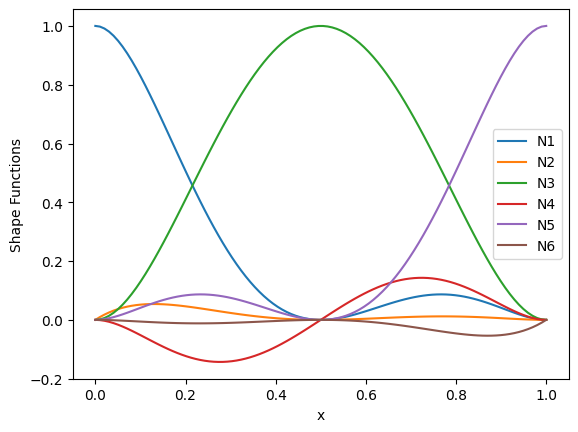

In [ ]:
# STIFFNESS MATRIX AND SHAPE FUNCTION FOR BEAM ELEMENT

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# Defining symbols
I, E, L, x = sp.symbols('I E L x')

# Input number of nodes
nodes = 2

# Defining Matrices
x_matrix = sp.Matrix([x**i for i in range(nodes*2)]).reshape(1, 2*nodes)
x_matrix_diff = sp.diff(x_matrix, x)

# Compute x_values
x_values = [i * (L / (nodes - 1)) for i in range(nodes)]
DA_matrix = []

# Construct DA_matrix
for i in range(nodes):
  DA_matrix.append(x_matrix.subs(x, x_values[i]))
  DA_matrix.append(x_matrix_diff.subs(x, x_values[i]))

# Compute the inverse
DA_matrix = sp.Matrix(DA_matrix)
DA_inv = DA_matrix.inv()

# Print Shape Function Matrix
Shape_function = x_matrix * DA_inv
print("Shape Function Matrix:")
print(Shape_function)

# Generating numeric x values for the plot
x_value_numeric = np.linspace(0, 1, 100)

# Plotting the Shape Functions
for i in range(2*nodes):
  shape = Shape_function[0, i]
  N = shape.subs(L, 1)
  N_values = [N.subs(x, x_value) for x_value in x_value_numeric]
  plt.plot(x_value_numeric, N_values, label=f'N{i+1}')
  plt.xlabel('x')
  plt.ylabel('Shape Functions')
  plt.legend()

# B and B_Transpose Matrix
B_matrix = sp.diff(sp.diff(Shape_function, x), x)
B_transpose = B_matrix.T

# Printing Stiffness Matrix
K = I * E * B_transpose * B_matrix
K = sp.integrate(K, (x, 0, L))
print("Stiffness Matrix:")
sp.pprint(K)

# Show the Plot
plt.show()


Enter the coordinates of node 1 (x, y): 1 1
Enter the coordinates of node 2 (x, y): 4 2
Enter the coordinates of node 3 (x, y): 3 5
Enter the coordinates of node 4 (x, y): 6 4
Enter the 3 node number of vertices of Triangle: 1 2 3
Shape Function Matrix:
Matrix([[0.074074074074074*x**2 - 0.685185185185185*x - 0.0555555555555557*y + 1.66666666666667, -0.12962962962963*x**2 + 1.07407407407407*x - 0.277777777777778*y - 0.666666666666666, -0.037037037037037*x**2 + 0.0925925925925925*x + 0.277777777777778*y - 0.333333333333333, 0.0925925925925925*x**2 - 0.481481481481481*x + 0.0555555555555554*y + 0.333333333333333]])


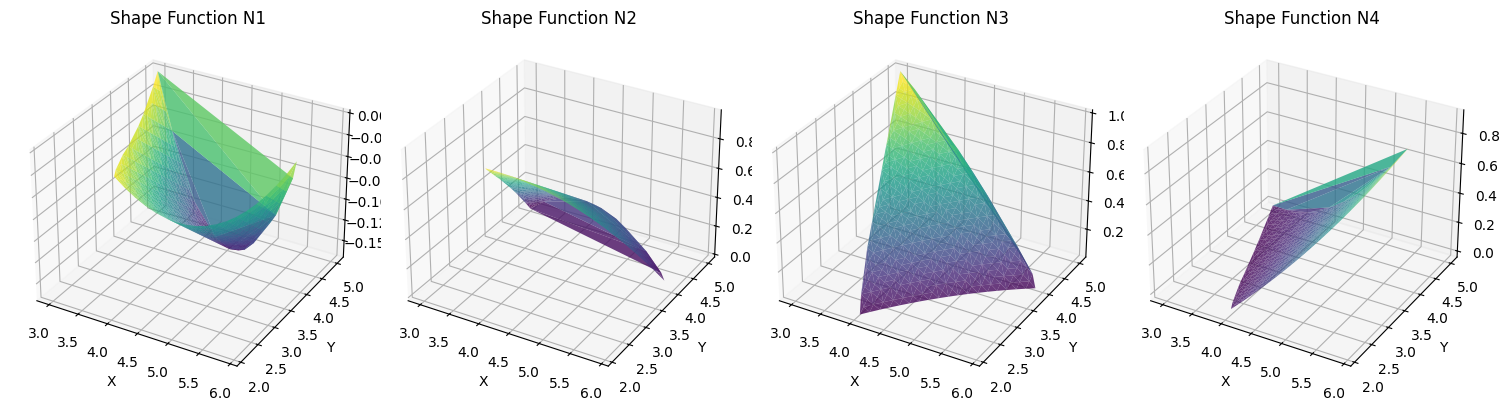

In [ ]:
# SHAPE FUNCTION OF A TRIANGULAR ELEMENT
import numpy as np
import sympy as sp
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# number of Nodes
nodes = 4  # int(input("Enter the number of nodes: "))

# Defining Symbol x and y
x, y = sp.symbols('x y')

# Extracting Coordinates of Triangle
nodes_coordinates = np.zeros((nodes, 2))
for i in range(nodes):
  coordinates = map(float, input(f"Enter the coordinates of node {i+1} (x, y): ").split())
  nodes_coordinates[i] = list(coordinates)

# Extracting node numbers of vertices
v = map(int, input(f"Enter the 3 node number of vertices of Triangle: ").split())
vertices = list(v)

# Function for Pascals Triangle
def pascals_triangle(n):
  coeff = []
  for i in range(n):
    coeff.append(x**(n-i-1) * y**(i))
  return coeff

# Function to extract coefficients
def coeff_extractor(n):
  coeffs = []
  for i in range(1, 10):
    for j in range(i):
      coeffs.append(pascals_triangle(i)[j])
  c = []
  for i in range(n):
    c.append(coeffs[i])
  return c

# Defining DA Matrix andd Coefficient matrix
DA_matrix = np.zeros((nodes, nodes))
u_xy = sp.Matrix(coeff_extractor(nodes))

# Loop to calculate DA_matrix
for i in range(nodes):
  for j in range(nodes):
    DA_matrix[i, j] = u_xy[j].subs(x, nodes_coordinates[i, 0]).subs(y, nodes_coordinates[i, 1])

# DA Inverse
DA_inv = np.linalg.inv(DA_matrix)

# Printing Shape Function
Shape_function = u_xy.T * DA_inv
print("Shape Function Matrix:")
print(Shape_function)

# Plot Shape Functions in Separate Subplots
fig, axes = plt.subplots(1, nodes, figsize=(15, 5), subplot_kw={'projection': '3d'})

# Extract triangle vertex coordinates
n1, n2, n3 = vertices
x1, y1 = nodes_coordinates[n1]
x2, y2 = nodes_coordinates[n2]
x3, y3 = nodes_coordinates[n3]

# Generate grid points within the triangle
num_points = 30
x_vals = np.linspace(min(x1, x2, x3), max(x1, x2, x3), num_points)
y_vals = np.linspace(min(y1, y2, y3), max(y1, y2, y3), num_points)
X, Y = np.meshgrid(x_vals, y_vals)
X, Y = X.flatten(), Y.flatten()

# Condition to keep points inside the triangle
def is_inside_triangle(xp, yp):
    A = 0.5 * (-y2*x3 + y1*(-x2 + x3) + x1*(y2 - y3) + x2*y3)
    s = 1 / (2*A) * (y1*x3 - x1*y3 + (y3 - y1)*xp + (x1 - x3)*yp)
    t = 1 / (2*A) * (x1*y2 - y1*x2 + (y1 - y2)*xp + (x2 - x1)*yp)
    return (s >= 0) & (t >= 0) & (1 - s - t >= 0)

# Keep only valid points
valid_points = np.array([is_inside_triangle(X[i], Y[i]) for i in range(len(X))])
X, Y = X[valid_points], Y[valid_points]

# Compute shape functions and plot each separately
for i in range(nodes):
    ax = axes[i]
    Z = np.array([Shape_function[i].subs({x: X[j], y: Y[j]}) for j in range(len(X))], dtype=float)

    ax.plot_trisurf(X, Y, Z, cmap='viridis', alpha=0.8)
    ax.set_title(f"Shape Function N{i+1}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("N")

plt.tight_layout()
plt.show()

In [ ]:
# SHAPE FUNCTION OF A QUADRILATERAL ELEMENT
import numpy as np
import sympy as sp
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# number of Nodes
nodes = 4  # int(input("Enter the number of nodes: "))

# Defining Symbol x and y
x, y = sp.symbols('x y')

# Extracting Coordinates of Triangle
nodes_coordinates = np.zeros((nodes, 2))
for i in range(nodes):
  coordinates = map(float, input(f"Enter the coordinates of node {i+1} (x, y): ").split())
  nodes_coordinates[i] = list(coordinates)

# Extracting node numbers of vertices
v = map(int, input(f"Enter the 3 node number of vertices of Triangle: ").split())
vertices = list(v)

# Function for Pascals Triangle
def pascals_triangle(n):
  coeff = []
  for i in range(n):
    coeff.append(x**(n-i-1) * y**(i))
  return coeff

# Function to extract coefficients
def coeff_extractor(n):
  coeffs = []
  for i in range(1, 10):
    for j in range(i):
      coeffs.append(pascals_triangle(i)[j])
  c = []
  for i in range(n):
    c.append(coeffs[i])
  return c

# Defining DA Matrix andd Coefficient matrix
DA_matrix = np.zeros((nodes, nodes))
u_xy = sp.Matrix(coeff_extractor(nodes))

# Loop to calculate DA_matrix
for i in range(nodes):
  for j in range(nodes):
    DA_matrix[i, j] = u_xy[j].subs(x, nodes_coordinates[i, 0]).subs(y, nodes_coordinates[i, 1])

# DA Inverse
DA_inv = np.linalg.inv(DA_matrix)

# Printing Shape Function
Shape_function = u_xy.T * DA_inv
print("Shape Function Matrix:")
print(Shape_function)

# Plot Shape Functions in Separate Subplots
fig, axes = plt.subplots(1, nodes, figsize=(15, 5), subplot_kw={'projection': '3d'})

# Extract triangle vertex coordinates
n1, n2, n3 = vertices
x1, y1 = nodes_coordinates[n1]
x2, y2 = nodes_coordinates[n2]
x3, y3 = nodes_coordinates[n3]

# Generate grid points within the triangle
num_points = 30
x_vals = np.linspace(min(x1, x2, x3), max(x1, x2, x3), num_points)
y_vals = np.linspace(min(y1, y2, y3), max(y1, y2, y3), num_points)
X, Y = np.meshgrid(x_vals, y_vals)
X, Y = X.flatten(), Y.flatten()

# Condition to keep points inside the triangle
def is_inside_triangle(xp, yp):
    A = 0.5 * (-y2*x3 + y1*(-x2 + x3) + x1*(y2 - y3) + x2*y3)
    s = 1 / (2*A) * (y1*x3 - x1*y3 + (y3 - y1)*xp + (x1 - x3)*yp)
    t = 1 / (2*A) * (x1*y2 - y1*x2 + (y1 - y2)*xp + (x2 - x1)*yp)
    return (s >= 0) & (t >= 0) & (1 - s - t >= 0)

# Keep only valid points
valid_points = np.array([is_inside_triangle(X[i], Y[i]) for i in range(len(X))])
X, Y = X[valid_points], Y[valid_points]

# Compute shape functions and plot each separately
for i in range(nodes):
    ax = axes[i]
    Z = np.array([Shape_function[i].subs({x: X[j], y: Y[j]}) for j in range(len(X))], dtype=float)

    ax.plot_trisurf(X, Y, Z, cmap='viridis', alpha=0.8)
    ax.set_title(f"Shape Function N{i+1}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("N")

plt.tight_layout()
plt.show()